# Exercise PT-P2 — Neural Network Training and Testing

**Carl Angelo Patano** · College of Computer Studies · Jose Rizal University · ITC-C508

Telecom Customer Support Intent Classifier — Keras rebuild of the PT-P1 no-code model.

**Target to beat:** PT-P1 benchmark of 90.91% accuracy / 0.915 macro F1.

### Running one experiment
| Step | Action | Why |
|---|---|---|
| 1 | Edit `CONFIG` (Section 2) — one value only | One change per run is the only way to attribute a result to a cause |
| 2 | **Runtime → Restart and run all** | Weights, vocabulary and the data split all persist in memory otherwise, so a re-run of a single cell is not a clean experiment |
| 3 | Copy the `EXP LOG ENTRY` block into the Excel log | The printed block is the evidence; retyping from memory invites errors |
| 4 | Save the loss curve as `EXP-xx_loss_curve.png` | Required for Task 3 and for the report figures |

---
## Section 0 — Environment Setup

**Why everything is in one cell:** every later cell depends on these imports and seeds. Keeping
them together means a runtime restart followed by this single cell is enough to make any other
cell runnable, which is what makes "Restart and run all" safe.

**Why two seed lines and not one:**

| Line | Controls | Consequence if omitted |
|---|---|---|
| `np.random.seed(42)` | NumPy randomness — the shuffling inside `train_test_split` | The train/val/test split changes between runs |
| `tf.random.set_seed(42)` | TensorFlow randomness — Keras initial layer weights | The starting weights change between runs |
| `random.seed(42)` + `tf.keras.utils.set_random_seed(42)` | Python's own `random` module, and TensorFlow **op-level** seeds | Weights depend on how many TF ops were created earlier in the session |
| `tf.config.experimental.enable_op_determinism()` | Kernel reduction order on GPU and some CPU paths | Identical seeds still produce different results from run to run |

Both are required. With only one set, two runs of the same configuration give different
answers and the comparison between experiments becomes meaningless.

**Why the first two seed lines were not sufficient — verified, not assumed:** EXP-01 was re-run
under an identical configuration in a clean session and did **not** reproduce. The final training
loss moved from 0.5933 to roughly 0.55 while the shape of the curve stayed the same. The cause is
that `np.random.seed` and `tf.random.set_seed` fix only the *global* seeds. Python's own `random`
module stays unseeded, and TensorFlow derives each operation's seed from an internal session
counter, so the initial weights depend on how many TF operations were created beforehand. A clean
*Restart and run all* and a session with prior cell executions therefore diverge from the same
seed value.

This matters beyond tidiness. An experiment log records a seed so that a configuration can be
re-run and checked. If the seed does not actually determine the result, every row in the log is
unverifiable, and the difference between two runs reflects initialisation noise as much as the
hyperparameter that was deliberately changed.

**Why 42 specifically:** the value is arbitrary; what matters is that it is fixed and recorded.
Any constant works as long as it never changes across the experiment series.

**Why the device is printed:** GPU and CPU kernels use different reduction orders, so the hardware
changes results even under identical seeds. The runtime type must therefore stay constant across
every run in the series, and printing it means each run documents the hardware that produced it.

In [1]:
# --- Drive mount: the dataset CSVs live in my Drive, not in the Colab session ---
# Colab storage is wiped when the runtime disconnects, so reading from Drive keeps
# the dataset stable across every experiment run.
from google.colab import drive
drive.mount('/content/drive')

# --- Data handling ---
import pandas as pd          # CSV loading; the dataset arrives as a dataframe
import numpy as np           # Keras consumes NumPy arrays, not Python lists

# --- Deep learning framework ---
import tensorflow as tf
from tensorflow.keras.models import Sequential                 # layers run in a fixed order, so a linear stack is sufficient
from tensorflow.keras.layers import (Embedding, GlobalAveragePooling1D,
                                     Dense, Dropout, Input)
from tensorflow.keras.optimizers import Adam, SGD              # both imported so the optimizer can be switched from CONFIG
from tensorflow.keras.callbacks import EarlyStopping           # Pillar 3 addition, off by default
from tensorflow.keras.regularizers import l2                   # weight decay, Pillar 3 addition, off by default

# --- Splitting and metrics ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, accuracy_score, precision_score,
                             recall_score, confusion_matrix, roc_auc_score)

# --- Utilities ---
from collections import Counter      # word frequency counting for the vocabulary
import matplotlib.pyplot as plt      # loss curve plotting
import os, random                    # required by the hardened reproducibility block below

# --- Reproducibility: both generators, see justification above ---
np.random.seed(42)
tf.random.set_seed(42)

# --- Reproducibility, hardened -------------------------------------------------
# The two lines above fix only the GLOBAL seeds, and testing showed that is NOT
# enough: an identical configuration re-run in a clean session produced a
# different final training loss. Three sources of drift remain uncontrolled:
#
#   1. Python's own `random` module is never seeded by either line above.
#   2. TensorFlow derives each operation's seed from an internal session counter,
#      so the weights depend on how many TF ops were created earlier in that
#      session. A clean "Restart and run all" and a session with prior cell
#      executions therefore give different starting weights from the same seed.
#   3. GPU and some CPU kernels use non-deterministic reduction orders, so
#      results move even when every seed is fixed.
#
# Caveat: PYTHONHASHSEED only takes full effect when set before the interpreter
# starts, so in Colab it is a precaution rather than a guarantee. The three lines
# beneath it do the actual work.
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
tf.keras.utils.set_random_seed(42)              # seeds python random + numpy + tensorflow together
tf.config.experimental.enable_op_determinism()  # forces deterministic kernel implementations

print("TensorFlow version:", tf.__version__)

# Hardware is recorded because it changes results even under identical seeds.
# The runtime type must stay the same for every run in the experiment series.
print("Devices:", [d.device_type for d in tf.config.list_physical_devices()])
print("Determinism enabled.")
print("Setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
Devices: ['CPU']
Determinism enabled.
Setup complete.


---
## Section 1 — Load and Preprocess the Dataset

Raw sentences cannot enter a neural network. This section converts them to fixed-length integer
arrays and splits those arrays three ways.

### Justification for each preprocessing decision

| Decision | Value | Why |
|---|---|---|
| `DATASET` switch | `original` / `expanded` | Data volume is a variable like any other. Switching it is its own experiment, not something changed quietly alongside a hyperparameter |
| Lowercase every word | — | "Slow" and "slow" carry identical meaning here; treating them as two tokens splits the evidence for that word in half |
| `MAX_LEN` | 20 | The longest sentence in the dataset is 14 words. 20 covers every sentence with margin, so nothing is truncated, while keeping the input small |
| `MAX_VOCAB_SIZE` | 1000 | A ceiling on vocabulary size. Rare words become `<UNK>` rather than each getting their own barely-trained embedding row |
| Index 0 = `<PAD>` | — | `mask_zero=True` in the Embedding layer treats index 0 as padding by convention, so padding must occupy index 0 |
| Index 1 = `<UNK>` | — | Words unseen at training time need somewhere to go; without this the encoder would crash on new input |
| Padding with 0 | — | Every input to the network must be the same length. Short sentences are filled to `MAX_LEN` |
| Truncation | — | Long sentences are cut to `MAX_LEN` for the same reason |
| Split ratio | 70 / 15 / 15 | Required by the exercise. Enough training data to learn, enough validation data for the score to mean something |
| Two-step split | — | `train_test_split` divides in two. Peeling off 30% and then halving it is how three sets are produced from a function that makes two |
| `stratify` | on both splits | Without it, a class can vanish entirely from the validation set at this dataset size, which makes per-class F1 undefined |
| `random_state=42` | — | Fixes the split so every experiment is scored on exactly the same validation sentences |

### Why three sets and not two
- **Train** — weights are updated from it.
- **Validation** — scored every epoch, never backpropagated. It measures generalisation while tuning.
- **Test** — untouched until the champion is chosen.

The validation set is unseen by the weights but **not unseen by me**: every time I read a
validation score and change a hyperparameter, information from it leaks into the model through
my decisions. The test set exists because it is the only split that neither the weights nor my
choices were influenced by.

In [2]:
# =========================================================
# 1. LOAD & PREPROCESS DATA
# =========================================================

DRIVE_DIR = '/content/drive/MyDrive/NN Training/'

DATA_CONFIG = {
    # "original" = 40-row PT-P1 set  |  "expanded" = 225-row balanced set (75 per class)
    "DATASET":        "expanded",
    "APPEND_SAMPLE":  False,   # additionally concatenate the provided sample_dataset.csv
    "TEXT_COL":       "text",
    "LABEL_COL":      "label",
    "MAX_LEN":        20,      # longest sentence is 14 words, so nothing gets truncated
    "MAX_VOCAB_SIZE": 1000,    # rare words collapse into <UNK> instead of getting weak embeddings
}

CSV_PATHS = {
    "original": DRIVE_DIR + 'ptp1_dataset.csv',
    "expanded": DRIVE_DIR + 'ptp1_dataset_expanded.csv',
}

MAX_LEN        = DATA_CONFIG["MAX_LEN"]
MAX_VOCAB_SIZE = DATA_CONFIG["MAX_VOCAB_SIZE"]

# ---- Load ----
df = pd.read_csv(CSV_PATHS[DATA_CONFIG["DATASET"]])
print(f"Dataset '{DATA_CONFIG['DATASET']}': {len(df)} rows")

if DATA_CONFIG["APPEND_SAMPLE"]:
    df = pd.concat([df, pd.read_csv(DRIVE_DIR + 'sample_dataset.csv')], ignore_index=True)
    print(f"After appending sample_dataset.csv: {len(df)} rows")

# Class balance is printed because an imbalanced set would make accuracy misleading
print("\nClass distribution:")
print(df[DATA_CONFIG["LABEL_COL"]].value_counts().sort_index())


def build_vocab(texts, max_vocab_size):
    """Assign each frequent word a unique integer index.

    Lowercased so that casing does not split the evidence for a word.
    Only the most frequent words are kept: a word seen once cannot train a
    useful embedding row, and keeping it only adds parameters.
    """
    words = [word.lower() for text in texts for word in str(text).split()]
    word_counts = Counter(words)
    # minus 2 because indices 0 and 1 are reserved below
    most_common = word_counts.most_common(max_vocab_size - 2)
    vocab = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
    vocab['<PAD>'] = 0   # index 0 because mask_zero=True treats 0 as padding by convention
    vocab['<UNK>'] = 1   # catch-all so unseen words at inference do not crash the encoder
    return vocab


def text_to_sequence(text, vocab, max_len):
    """Turn one sentence into a fixed-length integer list.

    Fixed length is mandatory: the network's input shape is declared once and
    every sample must match it.
    """
    tokens = str(text).lower().split()
    seq = [vocab.get(token, 1) for token in tokens]   # default 1 = <UNK>
    if len(seq) < max_len:
        seq += [0] * (max_len - len(seq))             # pad
    else:
        seq = seq[:max_len]                           # truncate
    return seq


vocab = build_vocab(df[DATA_CONFIG["TEXT_COL"]].tolist(), MAX_VOCAB_SIZE)
encoded_texts = [text_to_sequence(t, vocab, MAX_LEN) for t in df[DATA_CONFIG["TEXT_COL"]]]

X_data = np.array(encoded_texts)
y_data = np.array(df[DATA_CONFIG["LABEL_COL"]].values)
num_classes = len(np.unique(y_data))   # read from the data, not hardcoded, so the output layer always matches

print(f"\nVocabulary size: {len(vocab)} tokens")
print(f"Input shape: {X_data.shape}   (samples x MAX_LEN)")
print(f"Number of classes: {num_classes}")


# ---- 70 / 15 / 15 split ----
# Done in two calls because train_test_split only ever produces two sets.
# stratify keeps class proportions intact; without it a class can disappear
# from validation entirely at this dataset size.
X_train, X_temp, y_train, y_temp = train_test_split(
    X_data, y_data, test_size=0.30, random_state=42, stratify=y_data)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nTrain: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

Dataset 'expanded': 225 rows

Class distribution:
label
0    75
1    75
2    75
Name: count, dtype: int64

Vocabulary size: 562 tokens
Input shape: (225, 20)   (samples x MAX_LEN)
Number of classes: 3

Train: 157 | Validation: 34 | Test: 34


---
## Section 2 — Hyperparameter Configuration (The Three Pillars)

**Why one dictionary:** this is the only cell edited between experiments. Collecting every
tunable value in one place makes each run a single documented change instead of edits scattered
across the notebook that are impossible to reconstruct afterwards.

**Why these are hyperparameters and the weights are not:** everything here is set by me *before*
training and stays fixed throughout. The weights are produced by the optimizer *during* training
from measured error. Different sources, different jobs — they never swap.

### Justification per hyperparameter

| Pillar | Name | What it controls | Why it is tunable |
|---|---|---|---|
| **1 Architecture** | `embed_dim` | Length of each word's vector | Too small cannot separate word meanings; too large adds parameters with no data to fit them |
| | `hidden_dim` | Neurons in the dense layer | Sets model capacity. Under-capacity underfits, over-capacity memorises |
| **2 Optimization** | `learning_rate` | Step size of each weight update | Highest-impact value. Too high oscillates or diverges; too low never converges |
| | `optimizer_type` | Adam or SGD | Adam adapts step size per parameter and is forgiving of a mistuned LR; SGD is fixed-step and included for comparison |
| | `batch_size` | Samples per weight update | Smaller batch = more updates per epoch = faster learning per epoch, noisier gradients |
| | `epochs` | Passes over the training set | Too few underfits; too many overfits once validation loss turns |
| **3 Regularization** | `dropout_rate` | Fraction of neurons disabled per pass | Stops the model leaning on any single neuron, forcing redundant representations |
| | `weight_decay` | L2 penalty on large weights | Shrinks weights toward zero, discouraging the model from fitting noise |
| | `early_stopping` | Halt when val loss stalls | Stops at the generalisation optimum rather than the memorisation optimum |

**Why `weight_decay` and `early_stopping` default to off:** neither exists in the provided
baseline code. Both are my own Pillar 3 additions. Leaving them disabled means EXP-01 reproduces
the professor's baseline exactly, so any later improvement is attributable rather than confounded.

**Why tune in this order — learning rate, then architecture, then regularization:** the learning
rate multiplies into every one of the thousands of weight updates, so its effect compounds and
dominates everything else. Regularization comes last because it only helps once the loss curves
actually show overfitting; adding dropout to a model that is already underfitting makes it worse.

In [3]:
# =========================================================
# 2. HYPERPARAMETER CONFIGURATION
# =========================================================
# EDIT THIS CELL ONLY, THEN: Runtime -> Restart and run all
# Change ONE value per run, otherwise the result cannot be attributed to a cause.

CONFIG = {
    "run_id":         "EXP-05-EXTENDED-TRAINING",

    # --- Pillar 1: Architecture ---
    "embed_dim":      32,      # vector length per word
    "hidden_dim":     64,      # capacity of the classifier

    # --- Pillar 2: Optimization & Training ---
    "learning_rate":  0.005,  # tune this first, it has the largest effect
    "optimizer_type": "Adam",  # "Adam" (adaptive) or "SGD" (fixed step)
    "batch_size":     32,      # samples processed before one weight update
    "epochs":         60,      # full passes over the training set

    # --- Pillar 3: Regularization ---
    "dropout_rate":   0.1,     # fraction of neurons switched off per training pass
    "weight_decay":   0.0,     # L2 strength; 0.0 = off (not present in the baseline)
    "early_stopping": True,   # stop when val_loss stalls (not present in the baseline)
    "es_patience":    8,       # epochs of no improvement tolerated before stopping
}
# Echoed so the output of every run documents the configuration that produced it
print(f"--- Configuration for {CONFIG['run_id']} ---")
for k, v in CONFIG.items():
    print(f"  {k:16s}: {v}")

--- Configuration for EXP-05-EXTENDED-TRAINING ---
  run_id          : EXP-05-EXTENDED-TRAINING
  embed_dim       : 32
  hidden_dim      : 64
  learning_rate   : 0.005
  optimizer_type  : Adam
  batch_size      : 32
  epochs          : 60
  dropout_rate    : 0.1
  weight_decay    : 0.0
  early_stopping  : True
  es_patience     : 8


---
## Section 3 — Model Architecture

### Justification per layer

| Layer | Why it is here | What it costs |
|---|---|---|
| `Input(shape=(MAX_LEN,))` | Declares the input shape explicitly so `model.summary()` works before fitting | None |
| `Embedding` | Converts an integer index into a trainable dense vector. Nothing about word meaning is programmed in — the vectors start random and are shaped by gradient descent | Most of the model's parameters live here |
| `mask_zero=True` | Tells later layers to ignore padding positions | Without it, a 6-word sentence padded to 20 would be diluted by 14 meaningless slots |
| `GlobalAveragePooling1D` | Collapses the `MAX_LEN × embed_dim` matrix into one `embed_dim` vector, so a variable-length sentence becomes a fixed-size input for the dense layer | **Discards word order entirely** — this is the same limitation that caused the negation failure in PT-P1 |
| `Dense(hidden_dim, relu)` | The actual classifier. ReLU passes positives through and clamps negatives to zero | Without a non-linear activation the whole network collapses into a single linear model |
| `Dropout` | Randomly disables neurons during training only | Inactive at prediction time, so it costs nothing at inference |
| `Dense(num_classes, softmax)` | Output layer. Softmax turns three raw scores into probabilities summing to 1 | — |

**Why the output layer size is not my choice:** it is determined by the target variable. Three
classes means exactly three output neurons. Binary classification would use one neuron with
sigmoid; regression would use one neuron with no activation. Reading `num_classes` from the data
rather than hardcoding 3 means this stays correct if a fourth class is ever added.

**Why dropout sits after the hidden layer and not after the output:** dropping output neurons
would randomly delete entire class predictions, which is not regularization — it is corruption.

**Why feature extraction is automatic here:** the Embedding and pooling layers together turn raw
text into a numeric feature vector without any hand-written rules. This is the same job that
would otherwise require manual feature engineering.

In [4]:
# =========================================================
# 3. KERAS SEQUENTIAL ARCHITECTURE
# =========================================================

# Regulariser object only when weight decay is enabled; None keeps the baseline unchanged
reg = l2(CONFIG["weight_decay"]) if CONFIG["weight_decay"] > 0 else None

model = Sequential(name=CONFIG["run_id"].replace("-", "_"))

# Explicit input shape so model.summary() can be printed before training
model.add(Input(shape=(MAX_LEN,), dtype="int32"))

# Pillar 1 — Embedding: integer index -> trainable dense vector.
# mask_zero=True so padded positions do not dilute the sentence average below.
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    mask_zero=True
))

# Averages across the token axis: (MAX_LEN x embed_dim) -> (embed_dim,)
# Gives the dense layer a fixed-size input regardless of sentence length.
# Trade-off: word order is lost.
model.add(GlobalAveragePooling1D())

# Pillar 1 — the classifier itself. ReLU provides the non-linearity;
# without it the whole stack reduces to a linear model.
model.add(Dense(CONFIG["hidden_dim"], activation='relu', kernel_regularizer=reg))

# Pillar 3 — dropout after the hidden layer, never after the output.
# Dropping outputs would delete class predictions rather than regularise.
model.add(Dropout(CONFIG["dropout_rate"]))

# Output size read from the data, not hardcoded, so it always matches the target variable
model.add(Dense(num_classes, activation='softmax'))

print("Architecture built.")

Architecture built.


---
## Section 4 — Optimizer and Compilation

Compiling attaches three things to the architecture: how error is measured, how weights move,
and what is reported per epoch.

### Justification

| Choice | Value | Why this and not the alternative |
|---|---|---|
| Optimizer | `Adam` | Adapts the effective step size per parameter, so it tolerates a slightly wrong learning rate. SGD applies one fixed step to every parameter and needs a much more careful LR |
| Loss | `sparse_categorical_crossentropy` | Correct for multi-class with **integer** labels (0/1/2). `categorical_crossentropy` expects one-hot and would raise a shape error; `binary_crossentropy` would run but produce meaningless numbers |
| Metric | `accuracy` | Cheap to compute and readable per epoch. **Not** the metric I optimise for — weighted F1 in Section 5 is what goes in the log, because accuracy alone hides per-class failure when classes are unevenly represented |

**Why loss and metric are different things:** the loss is what gradient descent minimises, so it
must be differentiable. Accuracy is a counting operation with no useful gradient — it can be
reported but cannot be optimised directly.

In [5]:
# =========================================================
# 4. OPTIMIZER & COMPILATION
# =========================================================

# Adam by default: adaptive per-parameter step size, forgiving of a mistuned LR.
# SGD available from CONFIG so the two can be compared in a Task 4 run.
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(
    # sparse_* because labels are integers 0/1/2, not one-hot vectors
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    # accuracy is reported per epoch for monitoring only; weighted F1 is the logged metric
    metrics=['accuracy']
)

model.summary()

Model: "EXP_05_EXTENDED_TRAINING"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 32)         │        17,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,291 (79.26 KB)

 Trainable params: 20,291 (79.26 KB)

 Non-trainable params: 0 (0.00 B)

---
## Section 5 — The Operational Loop (Fit and Evaluate)

### Why `model.fit()` is the whole training loop
All four steps from the lecture happen inside this single call, repeated once per batch:

| Step | What happens | Where |
|---|---|---|
| 1. Forward pass | A batch flows through the layers and the model predicts | Inside `fit` |
| 2. Loss calculation | Prediction is compared to the true label; error computed | Inside `fit` |
| 3. Backward pass | Error is traced back to find each weight's contribution | Inside `fit` |
| 4. Weight update | Optimizer nudges every weight to reduce loss | Inside `fit` |

**Why an epoch is not one weight update:** weights update once per **batch**, not per epoch. With
157 training samples and `batch_size=32`, that is 5 batches per epoch — so 15 epochs is roughly
75 updates, not 15. This is why batch size and dataset size interact so strongly.

### Justification for the evaluation choices

| Choice | Why |
|---|---|
| `validation_data=(X_val, y_val)` | Runs the forward pass and loss only. No backward pass, no weight update — which is what makes `val_loss` a real generalisation signal instead of a second training score |
| `np.argmax(probs, axis=1)` | The model outputs three probabilities; the predicted class is the highest one |
| `average='weighted'` on F1 | Accounts for uneven class counts. Macro would treat a 5-sample class as equal to a 50-sample class |
| `zero_division=0` | A class with no predictions would otherwise raise a warning and return NaN mid-run |
| `restore_best_weights=True` | Without it, early stopping keeps the *last* weights, which are `patience` epochs past the best ones |
| ROC-AUC uses `val_probs` not `val_preds` | AUC measures ranking quality across thresholds, so it needs the probabilities. Feeding it hardened labels discards exactly the information it measures |
| `try/except` around ROC-AUC | Raises a `ValueError` when a class is absent from the validation split. Catching it stops one optional metric from killing the whole run |
| Macro F1 reported alongside weighted | PT-P1 reported **macro** averages, weighting every class equally regardless of size. A weighted score is not interchangeable with it, so the benchmark comparison needs the same averaging on both sides. On the balanced expanded set the two nearly coincide, which is itself worth stating |

In [6]:
# =========================================================
# 5. THE OPERATIONAL LOOP (FIT & EVALUATE)
# =========================================================
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

# Pillar 3 addition, disabled in the baseline.
# restore_best_weights matters: without it the model keeps the LAST weights,
# which are `patience` epochs past the best ones.
callbacks = []
if CONFIG["early_stopping"]:
    callbacks.append(EarlyStopping(
        monitor='val_loss',
        patience=CONFIG["es_patience"],
        restore_best_weights=True,
        verbose=1
    ))

# All four training steps happen inside this call, once per batch.
# validation_data runs forward pass + loss only, never a weight update.
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=callbacks,
    verbose=1
)

# ---- Validation metrics ----
val_probs = model.predict(X_val, verbose=0)      # three probabilities per sample
val_preds = np.argmax(val_probs, axis=1)         # predicted class = highest probability

# weighted averaging because the class counts are not identical;
# zero_division=0 prevents a NaN if a class receives no predictions
val_acc       = accuracy_score(y_val, val_preds)
val_f1        = f1_score(y_val, val_preds, average='weighted')
val_precision = precision_score(y_val, val_preds, average='weighted', zero_division=0)
val_recall    = recall_score(y_val, val_preds, average='weighted', zero_division=0)

# Macro F1 added so the comparison against PT-P1 is like-for-like.
# PT-P1 reported MACRO averages (every class weighted equally regardless of size).
# Weighted averaging credits a larger class more, so the two are not
# interchangeable even though they nearly coincide on a balanced dataset.
val_f1_macro  = f1_score(y_val, val_preds, average='macro')

# Final-epoch values straight from the history object returned by fit()
train_loss = history.history['loss'][-1]
train_acc  = history.history['accuracy'][-1]
val_loss   = history.history['val_loss'][-1]

# ROC-AUC needs PROBABILITIES, not thresholded labels: it measures ranking
# quality across all thresholds, which hardened labels would discard.
# Wrapped because it raises if a class is missing from the validation split.
try:
    val_auc = roc_auc_score(y_val, val_probs, multi_class='ovr', average='weighted')
    auc_str = f"{val_auc:.4f}"
except ValueError as e:
    val_auc, auc_str = None, f"n/a ({e})"

print("\n" + "=" * 78)
print(f"EXP LOG ENTRY  —  {CONFIG['run_id']}")
print("=" * 78)
print(f"  Dataset         : {DATA_CONFIG['DATASET']} "
      f"({len(X_train)} train / {len(X_val)} val / {len(X_test)} test)")
print(f"  Hyperparameters : LR={CONFIG['learning_rate']} | Embed={CONFIG['embed_dim']} | "
      f"Hidden={CONFIG['hidden_dim']} | Dropout={CONFIG['dropout_rate']}")
print(f"                    Epochs={CONFIG['epochs']} | Batch={CONFIG['batch_size']} | "
      f"Optimizer={CONFIG['optimizer_type']} | WeightDecay={CONFIG['weight_decay']}")
print(f"  Epochs run      : {len(history.history['loss'])}")
print("-" * 78)
print(f"  Train Loss      : {train_loss:.4f}")
print(f"  Train Accuracy  : {train_acc*100:.2f}%")
print(f"  Val Loss        : {val_loss:.4f}")
print(f"  Val Accuracy    : {val_acc*100:.2f}%")
print(f"  Val Precision   : {val_precision:.4f}")
print(f"  Val Recall      : {val_recall:.4f}")
print(f"  Val F1 (wtd)    : {val_f1:.4f}")
print(f"  Val F1 (macro)  : {val_f1_macro:.4f}   <- compare THIS against PT-P1")
print(f"  Val ROC-AUC     : {auc_str}")
print("=" * 78)
print("  PT-P1 BENCHMARK : Accuracy 90.91% | Macro F1 0.915")
print(f"  BEATS BENCHMARK : {'YES' if val_f1 > 0.915 else 'NO'}  (on weighted F1)")
print(f"  BEATS BENCHMARK : {'YES' if val_f1_macro > 0.9153 else 'NO'}  (macro F1 vs macro F1)")
print("=" * 78)

# Printed because accuracy alone does not show WHICH class is failing
print("\nValidation confusion matrix (rows = actual, cols = predicted):")
print(confusion_matrix(y_val, val_preds))

--- Starting Training Run: EXP-05-EXTENDED-TRAINING ---
Epoch 1/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 259ms/step - accuracy: 0.4650 - loss: 1.0923 - val_accuracy: 0.6765 - val_loss: 1.0765
Epoch 2/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8981 - loss: 1.0415 - val_accuracy: 0.9118 - val_loss: 1.0159
Epoch 3/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9618 - loss: 0.9359 - val_accuracy: 0.9118 - val_loss: 0.8968
Epoch 4/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9809 - loss: 0.7454 - val_accuracy: 0.9118 - val_loss: 0.7200
Epoch 5/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9809 - loss: 0.5155 - val_accuracy: 0.8824 - val_loss: 0.5271
Epoch 6/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9809 - loss: 0.2951 - val_accuracy: 0.9118 - val_loss: 0.3721
Epoch 7/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9873 - loss: 0.1486 - val_accuracy: 0.8824 - val_loss: 0.2731
Epoch 8/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000

---
## Section 5B — Automatic Result Capture

**Why this exists:** copying numbers off the screen by hand is where transcription errors enter
a log. This cell appends the run's metrics straight to `experiment_results.csv` in Drive, so the
log is built by the same code that produced the numbers.

**Why it writes to Drive and not the Colab session:** a free Colab session disconnects after
roughly 90 minutes idle and takes local files with it. Drive survives.

**Why it replaces rather than appends on a repeated `run_id`:** re-running the same experiment
should correct the existing row, not create a second one that silently contradicts it.

At the end of all experiments, download `experiment_results.csv` — it is the raw material for
the Excel log.

In [7]:
# =========================================================
# 5B. APPEND THIS RUN TO THE RESULTS CSV
# =========================================================
import os

RESULTS_CSV = DRIVE_DIR + 'experiment_results.csv'

row = {
    "run_id":        CONFIG["run_id"],
    "dataset":       DATA_CONFIG["DATASET"],
    "n_train":       len(X_train),
    "n_val":         len(X_val),
    "n_test":        len(X_test),
    "vocab_size":    len(vocab),
    "embed_dim":     CONFIG["embed_dim"],
    "hidden_dim":    CONFIG["hidden_dim"],
    "learning_rate": CONFIG["learning_rate"],
    "optimizer":     CONFIG["optimizer_type"],
    "batch_size":    CONFIG["batch_size"],
    "epochs_set":    CONFIG["epochs"],
    "epochs_run":    len(history.history['loss']),
    "dropout_rate":  CONFIG["dropout_rate"],
    "weight_decay":  CONFIG["weight_decay"],
    "early_stop":    CONFIG["early_stopping"],
    "train_loss":    round(train_loss, 4),
    "train_acc":     round(train_acc * 100, 2),
    "val_loss":      round(val_loss, 4),
    "val_acc":       round(val_acc * 100, 2),
    "val_precision": round(val_precision, 4),
    "val_recall":    round(val_recall, 4),
    "val_f1":        round(val_f1, 4),
    "val_f1_macro":  round(val_f1_macro, 4),
    "val_roc_auc":   round(val_auc, 4) if val_auc is not None else "n/a",
    "loss_gap":      round(val_loss - train_loss, 4),
    "best_epoch":    int(np.argmin(history.history['val_loss'])) + 1,
}

new_row = pd.DataFrame([row])

if os.path.exists(RESULTS_CSV):
    log_df = pd.read_csv(RESULTS_CSV)
    # replace instead of duplicating if this run_id was executed before
    log_df = log_df[log_df["run_id"] != CONFIG["run_id"]]
    log_df = pd.concat([log_df, new_row], ignore_index=True)
else:
    log_df = new_row

log_df.to_csv(RESULTS_CSV, index=False)
print(f"Saved to {RESULTS_CSV}  ({len(log_df)} run(s) logged)")
print("\nAll runs recorded so far:")
display(log_df[["run_id", "dataset", "learning_rate", "hidden_dim", "dropout_rate",
                "epochs_run", "train_loss", "val_loss", "val_acc", "val_f1"]])

Saved to /content/drive/MyDrive/NN Training/experiment_results.csv  (8 run(s) logged)

All runs recorded so far:


,run_id,dataset,learning_rate,hidden_dim,dropout_rate,epochs_run,train_loss,val_loss,val_acc,val_f1
0,EXP-01-KERAS-BASELINE,original,0.0050,64,0.1,15,0.6305,1.1555,16.67,0.0952
1,EXP-02-UNDERFIT,expanded,0.0001,16,0.0,15,1.0842,1.0888,55.88,0.5150
2,EXP-03-OVERFIT,expanded,0.0500,256,0.0,15,0.0000,1.0842,94.12,0.9405
3,EXP-04-REGULARIZED,expanded,0.0050,128,0.4,15,0.0014,0.1387,94.12,0.9395
4,EXP-05B-WEIGHT-DECAY,expanded,0.0050,64,0.1,56,0.0074,0.1142,94.12,0.9395
5,EXP-05B-EXTENDED-TRAINING,expanded,0.0050,64,0.1,56,0.0001,0.1067,94.12,0.9395
6,EXP-01B-EXPANDED-DATA,expanded,0.0050,64,0.1,15,0.0019,0.1200,94.12,0.9395
7,EXP-05-EXTENDED-TRAINING,expanded,0.0050,64,0.1,56,0.0001,0.1067,94.12,0.9395


---
## Section 6 — Loss Curve Diagnosis

**Why plot loss and not accuracy:** loss is continuous and reacts to *how wrong* a prediction is,
so it moves before accuracy does. Accuracy only changes when a prediction crosses the decision
boundary, which makes it a blunter and later signal.

**Why validation sits above training:** the weights were fitted on the training set, so the model
will always score better there. Training is the lower line. What matters is the **size of the gap**
and the **direction of the validation curve**.

### Diagnosis table

| Pattern | Diagnosis | Why | Fix |
|---|---|---|---|
| Both fall, stay close | **Good fit** | The model is learning patterns that transfer | Nothing — keep it |
| Train falls, validation flattens or rises, gap widens | **Overfitting** | The model is memorising training examples rather than extracting general patterns | More dropout, weight decay, early stopping, less capacity |
| Both stay high and flat | **Underfitting** | The model never captured the pattern — too little capacity, LR too low, or too few epochs | More epochs, higher LR, more capacity, **less** regularization |
| Loss spikes or goes NaN | **LR too high** | Updates overshoot the minimum and the oscillation compounds | Reduce learning rate |
| Train loss still falling at the last epoch | **Stopped too early** | Not underfitting — training was simply cut short | Add epochs (cheapest fix, costs only time) |

**Why the two fix lists are near mirror images:** applying an overfitting fix to an underfitting
model makes it worse. Diagnose before acting.

**Save the plot** — right-click, save as `EXP-xx_loss_curve.png`. Required for Task 3.

Loss curve saved to: /content/drive/MyDrive/NN Training/EXP-05-EXTENDED-TRAINING_loss_curve.png


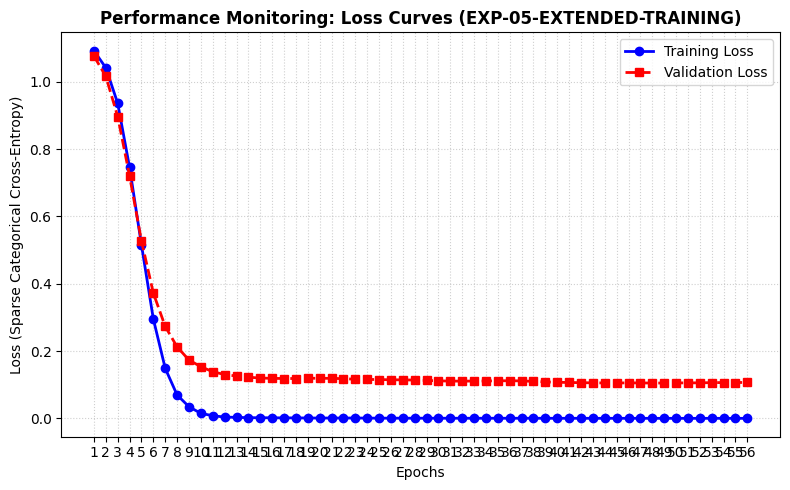

Final training loss   : 0.0001
Final validation loss : 0.1067
Final gap (val-train) : 0.1066   <- wide gap = overfitting
Best epoch (lowest val loss) : 48 of 56
   (best epoch well before the last = training continued past the optimum)

Read the chart against the diagnosis table above and record it in the log.


In [8]:
# =========================================================
# 6. GENERATE LOSS CURVES CHART
# =========================================================
train_losses = history.history['loss']
val_losses   = history.history['val_loss']

# Length taken from the history, not from CONFIG["epochs"], because early
# stopping may have ended the run before the configured epoch count
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss',
         color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss',
         color='red', linewidth=2, linestyle='--', marker='s')

plt.title(f"Performance Monitoring: Loss Curves ({CONFIG['run_id']})",
          fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# Saved automatically so the figure cannot be lost or mislabelled later.
# Saved BEFORE plt.show() because show() clears the figure buffer.
plot_path = DRIVE_DIR + f"{CONFIG['run_id']}_loss_curve.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Loss curve saved to: {plot_path}")

plt.show()

# Numbers behind the visual diagnosis, so the classification in the log is
# defensible rather than an impression of the chart
final_gap = val_losses[-1] - train_losses[-1]
print(f"Final training loss   : {train_losses[-1]:.4f}")
print(f"Final validation loss : {val_losses[-1]:.4f}")
print(f"Final gap (val-train) : {final_gap:.4f}   <- wide gap = overfitting")
print(f"Best epoch (lowest val loss) : {int(np.argmin(val_losses)) + 1} of {len(val_losses)}")
print("   (best epoch well before the last = training continued past the optimum)")
print("\nRead the chart against the diagnosis table above and record it in the log.")

---
## Section 7 — Final Test Set Evaluation (Champion Model Only)

**Why this cell is gated behind a flag:** the test set is the only split that neither the weights
nor my hyperparameter choices were influenced by. Running it after every experiment would defeat
that — I would start selecting configurations by test score, and it would become a second
validation set.

**Why the reported number stands whatever it says:** if I check the test score and then go back
and re-tune, the reported accuracy becomes optimistic and no longer estimates performance on
genuinely new data. So this runs once, on the champion only, at the very end.

**Why the validation-to-test gap is worth printing:** a small gap means the model generalises. A
large drop means the configuration was over-tuned against the validation set specifically.

In [9]:
# =========================================================
# 7. FINAL TEST SET EVALUATION — CHAMPION MODEL ONLY
# =========================================================
# Set True once, for the champion configuration only. See justification above.
RUN_TEST_EVALUATION = False

if RUN_TEST_EVALUATION:
    test_probs = model.predict(X_test, verbose=0)
    test_preds = np.argmax(test_probs, axis=1)

    test_acc = accuracy_score(y_test, test_preds)
    test_f1  = f1_score(y_test, test_preds, average='weighted')

    print("=" * 78)
    print(f"FINAL HELD-OUT TEST EVALUATION  —  {CONFIG['run_id']}")
    print("=" * 78)
    print(f"  Test samples  : {len(y_test)}")
    print(f"  Test Accuracy : {test_acc*100:.2f}%")
    print(f"  Test F1 (wtd) : {test_f1:.4f}")
    print("-" * 78)
    print(f"  Validation Accuracy : {val_acc*100:.2f}%")
    # Small gap = genuine generalisation; large drop = over-tuned against validation
    print(f"  Generalisation gap  : {(val_acc - test_acc)*100:+.2f} pts")
    print("=" * 78)
    print("\nTest confusion matrix (rows = actual, cols = predicted):")
    print(confusion_matrix(y_test, test_preds))
else:
    print("Test evaluation skipped. Set RUN_TEST_EVALUATION = True for the champion run only.")

Test evaluation skipped. Set RUN_TEST_EVALUATION = True for the champion run only.


---
## Section 7B — Cross-Evaluation on the PT-P1 Fixed Test Set

**Why this exists:** the validation score and the PT-P1 benchmark were measured on
*different tests*. PT-P1 was scored on eleven hand-authored phrases written specifically
to probe negation, sarcasm, and the complaint/urgent boundary. This notebook scores on a
random 15% slice of the dataset. Beating 90.91% on an easier test is not evidence of a
better model. This cell runs the Keras model on the **identical eleven phrases**, so the
no-code and coded models are finally compared on the same input.

**Why eleven and not twelve:** T12 (*"Can I update the email address on my account?"*)
belongs to none of the three classes and has no correct label by construction. It is
excluded from scoring and reported separately as an out-of-vocabulary confidence probe,
exactly as it was in PT-P1.

**Known advantage, to be disclosed in the report:** four phrases have high word overlap
with sentences in the expanded training set — T11 (0.82), T07 (0.67), T05 (0.64),
T09 (0.57). **None is an exact duplicate**; all twelve are verbatim-clean against the
training data. But those four are close paraphrases, so the Keras model has an advantage
the no-code model did not have. The per-phrase table flags them so the aggregate is never
read as fully independent.

**Why this is gated behind a flag:** same discipline as Section 7. Enable it for the
champion configuration only. Reading this score and then re-tuning would convert it into a
second validation set, and the reported figure would become optimistic.

### Prediction recorded before running

The architecture is `Embedding → GlobalAveragePooling1D`, which averages token vectors and
therefore **discards word order** — the same representational limit diagnosed in the PT-P1
report. So:

- **T05** (negation) — expected to pass now, since the expanded set contains negation
  examples and `not` has acquired weight toward the complaint class.
- **T10** (sarcasm, *"Oh wonderful, another outage…"*) — **expected to still fail.**
  `outage` is strongly bound to Urgent_Support and averaging cannot let `wonderful` modify
  it. This is the one failure PT-P1 never resolved either.
- **T07** (boundary) — expected to pass, high overlap with a training sentence.

If T10 fails again, that is not a defect. It is the same limitation surfacing in two
architecturally different systems, which is a stronger finding than either model alone.


In [10]:
# =========================================================
# 7B. CROSS-EVALUATION ON THE PT-P1 FIXED TEST SET
# =========================================================
# Set True for the champion configuration only. See justification above.
RUN_PTP1_CROSSEVAL = False

# The eleven scored phrases from PT-P1, verbatim, plus T12 as the OOV probe.
# Labels use this notebook's encoding: 0=Negative_Complaint, 1=Positive_Praise, 2=Urgent_Support
# near_dup flags phrases with high word overlap against the expanded training set.
PTP1_TESTSET = [
    # id,   phrase,                                                            label, case,       PT-P1 Step 5, near_dup
    ("T01", "The new router works perfectly, no complaints at all.",               1, "Clear",    "Pos 67 OK",  False),
    ("T02", "Very happy with how fast my concern was handled.",                    1, "Clear",    "Pos 97 OK",  False),
    ("T03", "Excellent coverage even in the province, well done.",                 1, "Clear",    "Pos 96 OK",  False),
    ("T04", "The connection drops every single evening without fail.",             0, "Clear",    "Neg 92 OK",  False),
    ("T05", "I am not satisfied with the quality of service lately.",              0, "Negation", "Neg 92 OK",  True),
    ("T06", "Support ticket has been open for a month with no update.",            0, "Clear",    "Neg 69 OK",  False),
    ("T07", "No signal at all and I have a client presentation in ten minutes.",   2, "Boundary", "Urg 77 OK",  True),
    ("T08", "Immediate help needed, my landline is completely dead.",              2, "Clear",    "Urg 91 OK",  False),
    ("T09", "Please restore my service now, I have already paid in full.",         2, "Clear",    "Urg 88 OK",  True),
    ("T10", "Oh wonderful, another outage right when I need the internet most.",   0, "Sarcasm",  "Urg 50 XX",  False),
    ("T11", "Fantastic, my bill went up again for absolutely no reason.",          0, "Sarcasm",  "Neg 72 OK",  True),
]
PTP1_OOV_PROBE = ("T12", "Can I update the email address on my account?", "PT-P1 conf: 3%")

CLASS_NAMES = {0: "Neg", 1: "Pos", 2: "Urg"}

# PT-P1 Step 5 benchmark, unrounded. 10/11 correct gives macro F1 = 0.915343915343...
# Kept at full precision because a rounded constant makes an exact tie read as a loss.
PTP1_ACC      = 10 / 11
PTP1_MACRO_F1 = 0.9153439153439153
TIE_TOL       = 1e-4   # 11 test cases cannot resolve finer than this

if RUN_PTP1_CROSSEVAL:
    # Encoded with the SAME vocabulary the model trained on. Words outside it become
    # <UNK>, which is exactly what happens to any genuinely unseen input at deployment.
    phrases = [row[1] for row in PTP1_TESTSET]
    y_ptp1  = np.array([row[2] for row in PTP1_TESTSET])
    X_ptp1  = np.array([text_to_sequence(p, vocab, MAX_LEN) for p in phrases])

    probs_ptp1 = model.predict(X_ptp1, verbose=0)
    preds_ptp1 = np.argmax(probs_ptp1, axis=1)
    conf_ptp1  = probs_ptp1.max(axis=1) * 100

    acc_ptp1      = accuracy_score(y_ptp1, preds_ptp1)
    f1_macro_ptp1 = f1_score(y_ptp1, preds_ptp1, average='macro')

    print("=" * 96)
    print(f"PT-P1 FIXED TEST SET CROSS-EVALUATION  -  {CONFIG['run_id']}")
    print("=" * 96)
    print(f"{'ID':5s} {'Case':9s} {'Exp':4s} {'Keras':6s} {'Conf':8s} {'OK':3s} "
          f"{'PT-P1 Step5':13s} {'NearDup':7s}")
    print("-" * 96)
    for (tid, _, lab, case, ptp1, ndup), pred, conf in zip(PTP1_TESTSET, preds_ptp1, conf_ptp1):
        ok = "OK" if pred == lab else "XX"
        print(f"{tid:5s} {case:9s} {CLASS_NAMES[lab]:4s} {CLASS_NAMES[pred]:6s} "
              f"{conf:6.2f}%  {ok:3s} {ptp1:13s} {'yes' if ndup else '-':7s}")
    print("-" * 96)

    correct = int((preds_ptp1 == y_ptp1).sum())
    print(f"  Keras   : {correct}/11 correct | Accuracy {acc_ptp1*100:.2f}% | Macro F1 {f1_macro_ptp1:.4f}")
    print(f"  PT-P1   : 10/11 correct | Accuracy {PTP1_ACC*100:.2f}% | Macro F1 {PTP1_MACRO_F1:.4f}")
    print(f"  Delta   : {(acc_ptp1 - PTP1_ACC)*100:+.2f} pts accuracy | "
          f"{f1_macro_ptp1 - PTP1_MACRO_F1:+.4f} macro F1")
    print("-" * 96)

    # This is the figure the report should lead with, not the validation-split score,
    # because it is the only comparison that holds the test constant.
    # Tie is checked FIRST and with a real tolerance. With only 11 scored cases the
    # two models can land on identical predictions; a rounded constant plus a 1e-9
    # tolerance would report that exact tie as a loss.
    if abs(f1_macro_ptp1 - PTP1_MACRO_F1) < TIE_TOL:
        verdict = "MATCHES"
    elif f1_macro_ptp1 > PTP1_MACRO_F1:
        verdict = "BEATS"
    else:
        verdict = "LOSES TO"
    print(f"  VERDICT : Keras model {verdict} the PT-P1 no-code model on the identical test set.")
    print("-" * 96)

    # Reported separately: no correct label exists, so it cannot be scored.
    # LOW confidence is the desirable outcome - it means the model recognises the
    # input as belonging to none of its three classes.
    oov_seq  = np.array([text_to_sequence(PTP1_OOV_PROBE[1], vocab, MAX_LEN)])
    oov_prob = model.predict(oov_seq, verbose=0)[0]
    print(f"  OOV probe {PTP1_OOV_PROBE[0]}: predicted {CLASS_NAMES[int(np.argmax(oov_prob))]} "
          f"at {oov_prob.max()*100:.2f}%  ({PTP1_OOV_PROBE[2]})")
    print("    Low confidence is the GOOD outcome here - no correct class exists.")
    print("=" * 96)

    print("\nConfusion matrix on the PT-P1 test set (rows = actual, cols = predicted):")
    print(confusion_matrix(y_ptp1, preds_ptp1))

    print("\nCaveat for the report: T05, T07, T09 and T11 have 0.57-0.82 word overlap with")
    print("training sentences in the expanded set. No exact duplicates, but this is an")
    print("advantage the no-code model did not have. State it in Limitations.")
else:
    print("PT-P1 cross-evaluation skipped. Set RUN_PTP1_CROSSEVAL = True for the champion run only.")


PT-P1 cross-evaluation skipped. Set RUN_PTP1_CROSSEVAL = True for the champion run only.
